<a href="https://colab.research.google.com/github/santyxd3000/Undergraduate-Project/blob/main/Graph_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np


In [2]:
#Table Measurements Train

autoencoders_metrics_train = pd.read_csv('autoencoders_metrics_train.csv')
autoencoders_metrics_test = pd.read_csv('autoencoders_metrics_test.csv')
autoencoders_confusion_matrix_train = pd.read_csv('autoencoders_confusion_matrix_train.csv')
autoencoders_confusion_matrix_test = pd.read_csv('autoencoders_confusion_matrix_test.csv')


In [3]:
autoencoders_metrics_train

,Model,Precision,Accuracy,F1-Score,Recall
0,Model 1,0.897,0.822,0.467,0.317
1,Model 2,0.901,0.848,0.509,0.354
2,Model 3,0.885,0.915,0.645,0.507
3,Model 4,0.911,0.825,0.476,0.322
4,Model 5,0.919,0.814,0.464,0.310
5,Model 6,0.965,0.678,0.343,0.209
6,Model 7,0.961,0.836,0.506,0.343
7,Model 8,0.923,0.847,0.512,0.355
8,Model 9,0.938,0.849,0.521,0.361


In [28]:
autoencoders_confusion_matrix_train

,Model,True_Positive,True_Negative,False_Positive,False_Negative
0,Model 1,8013,76050,17256,917
1,Model 2,8051,78644,14662,879
2,Model 3,7899,85636,7670,1031
3,Model 4,8132,76182,17124,798
4,Model 5,8211,75053,18253,719
5,Model 6,8617,60660,32646,313
6,Model 7,8580,76879,16427,350
7,Model 8,8243,78304,15002,687
8,Model 9,8377,78456,14850,553


In [19]:
metrics = ["Precision", "Accuracy", "F1-Score", "Recall"]
figsize = (17, 10)
show_values = True
start_index = 1
n = len(autoencoders_metrics_train)
tick_labels = [f"Model {i}" for i in range(start_index, start_index + n)]

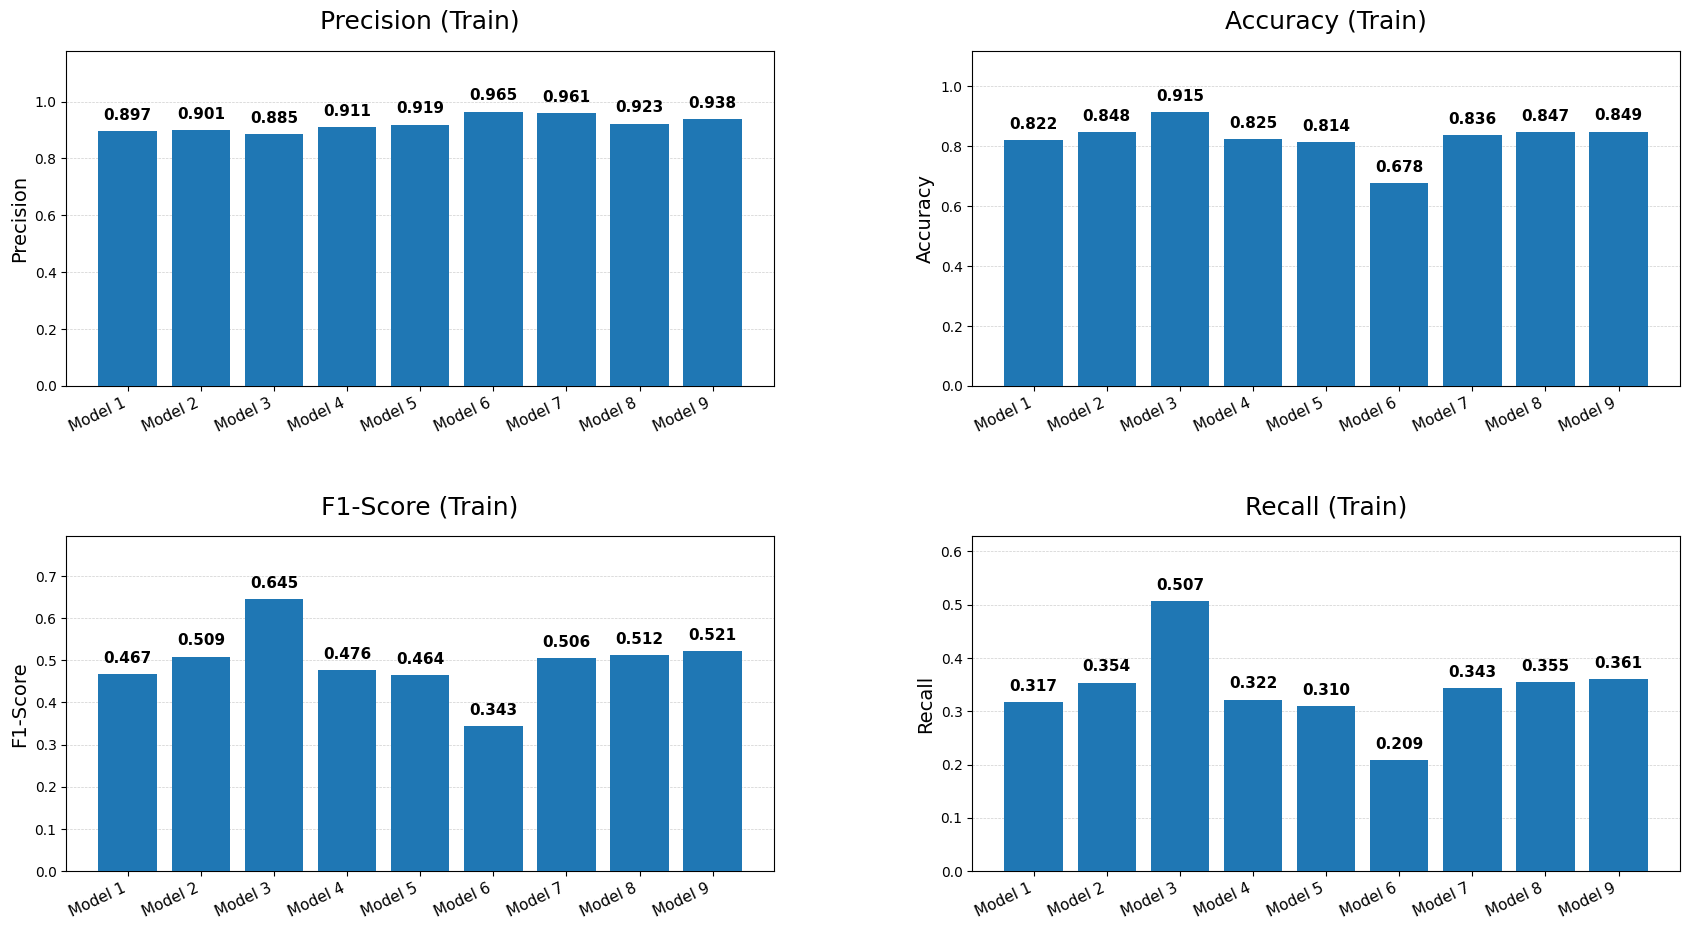

In [24]:
fig, axes = plt.subplots(2, 2, figsize=figsize)
axes = axes.flatten()
x = np.arange(n)  # numeric x positions

for ax, metric in zip(axes, metrics):
    if metric not in autoencoders_metrics_train.columns:
        raise ValueError(f"Metric '{metric}' not found in CSV columns: {autoencoders_metrics_train.columns.tolist()}")
    values = autoencoders_metrics_train[metric].values

    # draw bars
    bars = ax.bar(x, values, zorder=3)

    # compute comfortable y-limit so annotations fit
    top = values.max()
    if top <= 1:
        ylim_top = top * 1.20 + 0.02   # padding for decimal metrics
    else:
        ylim_top = top * 1.06 + 1      # for integer counts
    ax.set_ylim(0, ylim_top)

    # titles and labels (use pad to move title away from axis)
    ax.set_title(f"{metric} (Train)", fontsize=18, pad=16)
    ax.set_ylabel(metric, fontsize=14)

    # set numeric x positions and custom tick labels (Model 0, Model 1, ...)
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=25, ha="right", fontsize=11)

    # grid for readability (grid behind bars)
    ax.grid(axis="y", linewidth=0.5, linestyle="--", alpha=0.6, zorder=0)

    # annotate bar values (format decimals for <=1)
    if show_values:
        for rect in bars:
            height = rect.get_height()
            if height is None:
                continue
            if height > 1.0:
                label = f"{int(round(height))}"
            else:
                label = f"{height:.3f}"
            # small dynamic offset so labels are always readable
            y_offset = max(6, int(0.02 * ylim_top * 72))  # in points; scaled with ylim
            ax.annotate(
                label,
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, y_offset),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=11,
                weight="bold"
            )

# Make room for suptitle and increase spacing between subplots so titles don't overlap x-axis of above plots
plt.tight_layout(rect=[0, 0.02, 1, 0.94])   # leave top space for suptitle
fig.subplots_adjust(hspace=0.45, wspace=0.28, bottom=0.10, top=0.92)

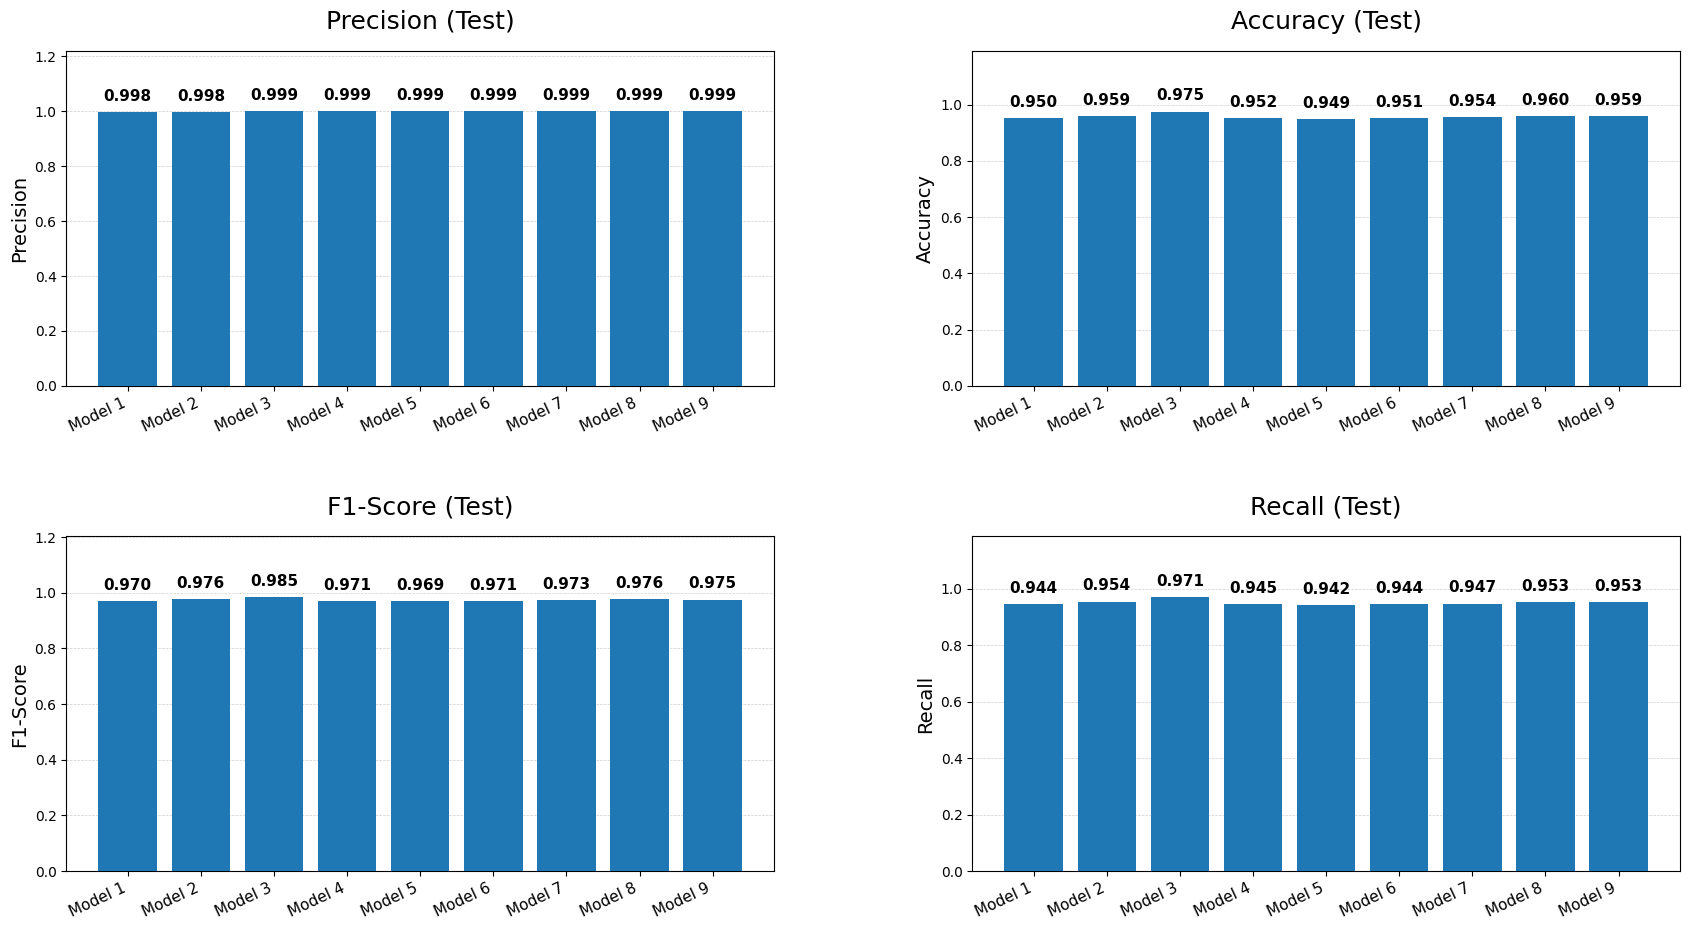

In [25]:
fig, axes = plt.subplots(2, 2, figsize=figsize)
axes = axes.flatten()
x = np.arange(n)  # numeric x positions

for ax, metric in zip(axes, metrics):
    if metric not in autoencoders_metrics_test.columns:
        raise ValueError(f"Metric '{metric}' not found in CSV columns: {autoencoders_metrics_test.columns.tolist()}")
    values = autoencoders_metrics_test[metric].values

    # draw bars
    bars = ax.bar(x, values, zorder=3)

    # compute comfortable y-limit so annotations fit
    top = values.max()
    if top <= 1:
        ylim_top = top * 1.20 + 0.02   # padding for decimal metrics
    else:
        ylim_top = top * 1.06 + 1      # for integer counts
    ax.set_ylim(0, ylim_top)

    # titles and labels (use pad to move title away from axis)
    ax.set_title(f"{metric} (Test)", fontsize=18, pad=16)
    ax.set_ylabel(metric, fontsize=14)

    # set numeric x positions and custom tick labels (Model 0, Model 1, ...)
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=25, ha="right", fontsize=11)

    # grid for readability (grid behind bars)
    ax.grid(axis="y", linewidth=0.5, linestyle="--", alpha=0.6, zorder=0)

    # annotate bar values (format decimals for <=1)
    if show_values:
        for rect in bars:
            height = rect.get_height()
            if height is None:
                continue
            if height > 1.0:
                label = f"{int(round(height))}"
            else:
                label = f"{height:.3f}"
            # small dynamic offset so labels are always readable
            y_offset = max(6, int(0.02 * ylim_top * 72))  # in points; scaled with ylim
            ax.annotate(
                label,
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, y_offset),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=11,
                weight="bold"
            )

# Make room for suptitle and increase spacing between subplots so titles don't overlap x-axis of above plots
plt.tight_layout(rect=[0, 0.02, 1, 0.94])   # leave top space for suptitle
fig.subplots_adjust(hspace=0.45, wspace=0.28, bottom=0.10, top=0.92)

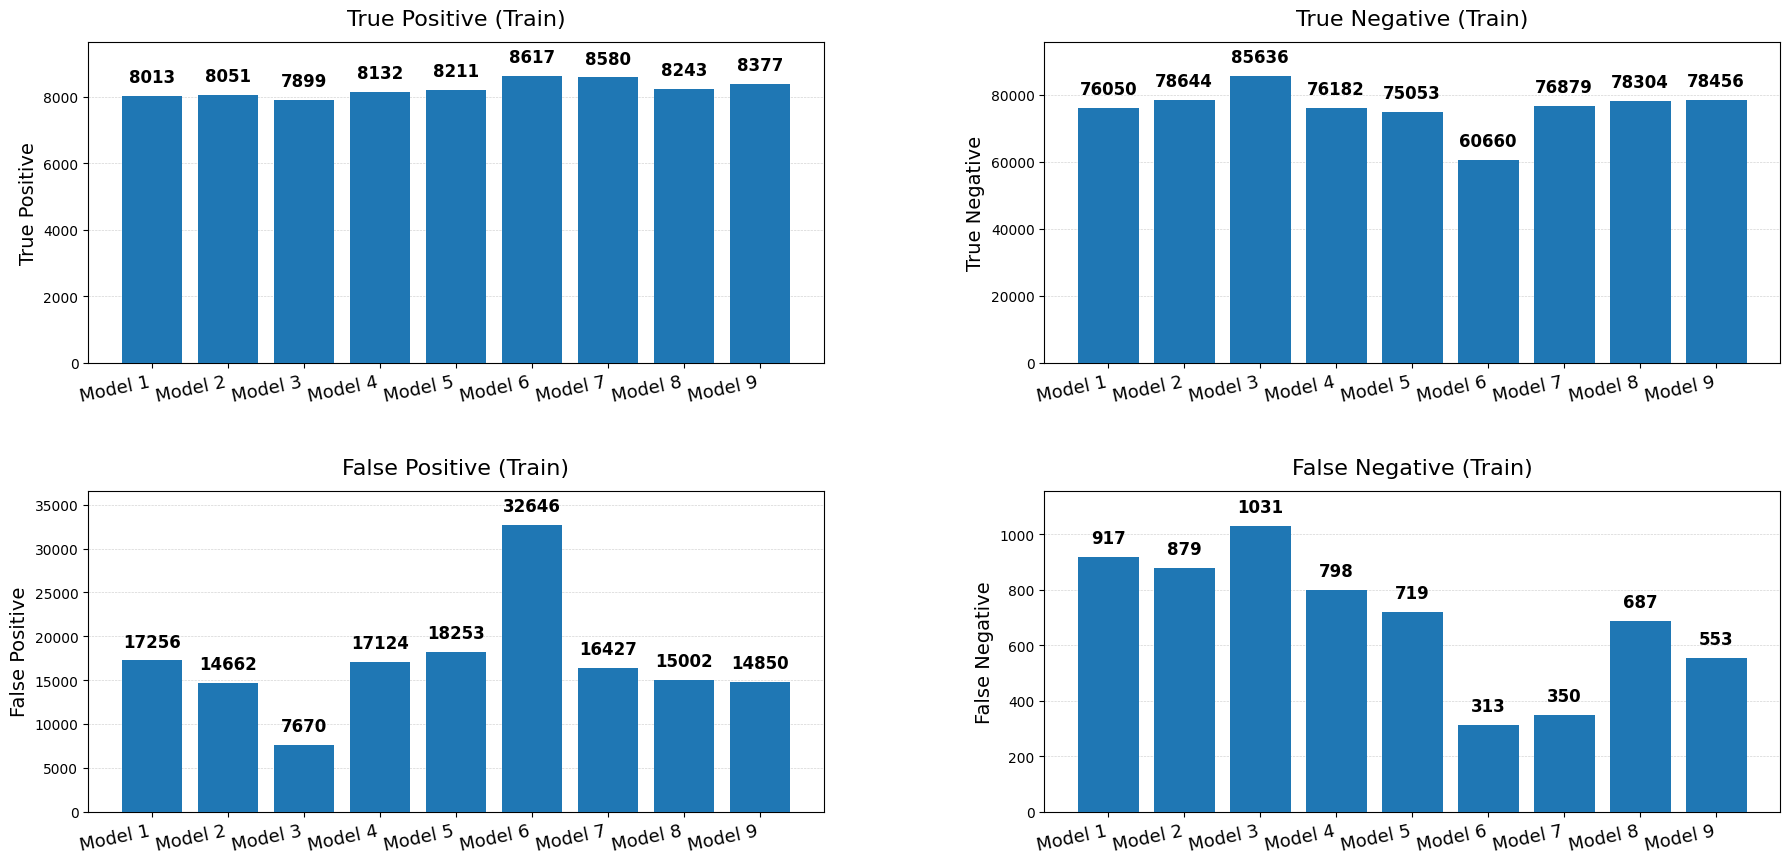

In [40]:
# column name variants to resolve
col_variants = {
    "True_Positive": ["True_Positive", "True Positive", "TP", "TruePositive"],
    "True_Negative": ["True_Negative", "True Negative", "TN", "TrueNegative"],
    "False_Positive": ["False_Positive", "False Positive", "FP", "FalsePositive"],
    "False_Negative": ["False_Negative", "False Negative", "FN", "FalseNegative"],
}

# resolve actual column names present in df
resolved = {}
for canon, variants in col_variants.items():
    for name in variants:
        if name in autoencoders_confusion_matrix_train.columns:
            resolved[canon] = name
            break
    else:
        raise KeyError(f"Could not find any column for '{canon}'. Tried: {variants}. Available: {list(autoencoders_confusion_matrix_train.columns)}")

# tick labels: prefer Model column if present, otherwise generate "Model 1"...
if "Model" in autoencoders_confusion_matrix_train.columns:
    tick_labels = autoencoders_confusion_matrix_train["Model"].astype(str).tolist()
else:
    tick_labels = [f"Model {i+1}" for i in range(len(autoencoders_confusion_matrix_train))]

x = np.arange(len(autoencoders_confusion_matrix_train))

# ------- PLOTTING (wider & larger) -------
figsize = (18, 10)         # <-- slightly wider
fig, axes = plt.subplots(2, 2, figsize=figsize)
axes = axes.flatten()

# font sizes tuned for readability
title_fs = 16
ylabel_fs = 14
xtick_fs = 13    # larger x tick labels
annot_fs = 12
show_values = True

order = ["True_Positive", "True_Negative", "False_Positive", "False_Negative"]
pretty = {
    "True_Positive": "True Positive",
    "True_Negative": "True Negative",
    "False_Positive": "False Positive",
    "False_Negative": "False Negative",
}

for ax, canon in zip(axes, order):
    colname = resolved[canon]
    vals = pd.to_numeric(autoencoders_confusion_matrix_train[colname].astype(str).str.replace(r"\s+", "", regex=True), errors="coerce").fillna(0).astype(int).values

    bars = ax.bar(x, vals, zorder=3)

    top = vals.max() if len(vals) else 0
    ax.set_ylim(0, top * 1.12 + 1)

    ax.set_title(f"{pretty[canon]} (Train)", fontsize=title_fs, pad=12)
    ax.set_ylabel(pretty[canon], fontsize=ylabel_fs)

    # wider spacing + larger readable labels; slight rotation (12 deg)
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=12, ha="right", fontsize=xtick_fs)

    ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.6, zorder=0)

    if show_values:
        for rect in bars:
            h = rect.get_height()
            ax.annotate(
                f"{int(round(h))}",
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=annot_fs, fontweight="bold"
            )

# layout adjustments: more bottom margin so labels fit comfortably
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.subplots_adjust(hspace=0.40, wspace=0.30, bottom=0.18, top=0.95)

plt.show()

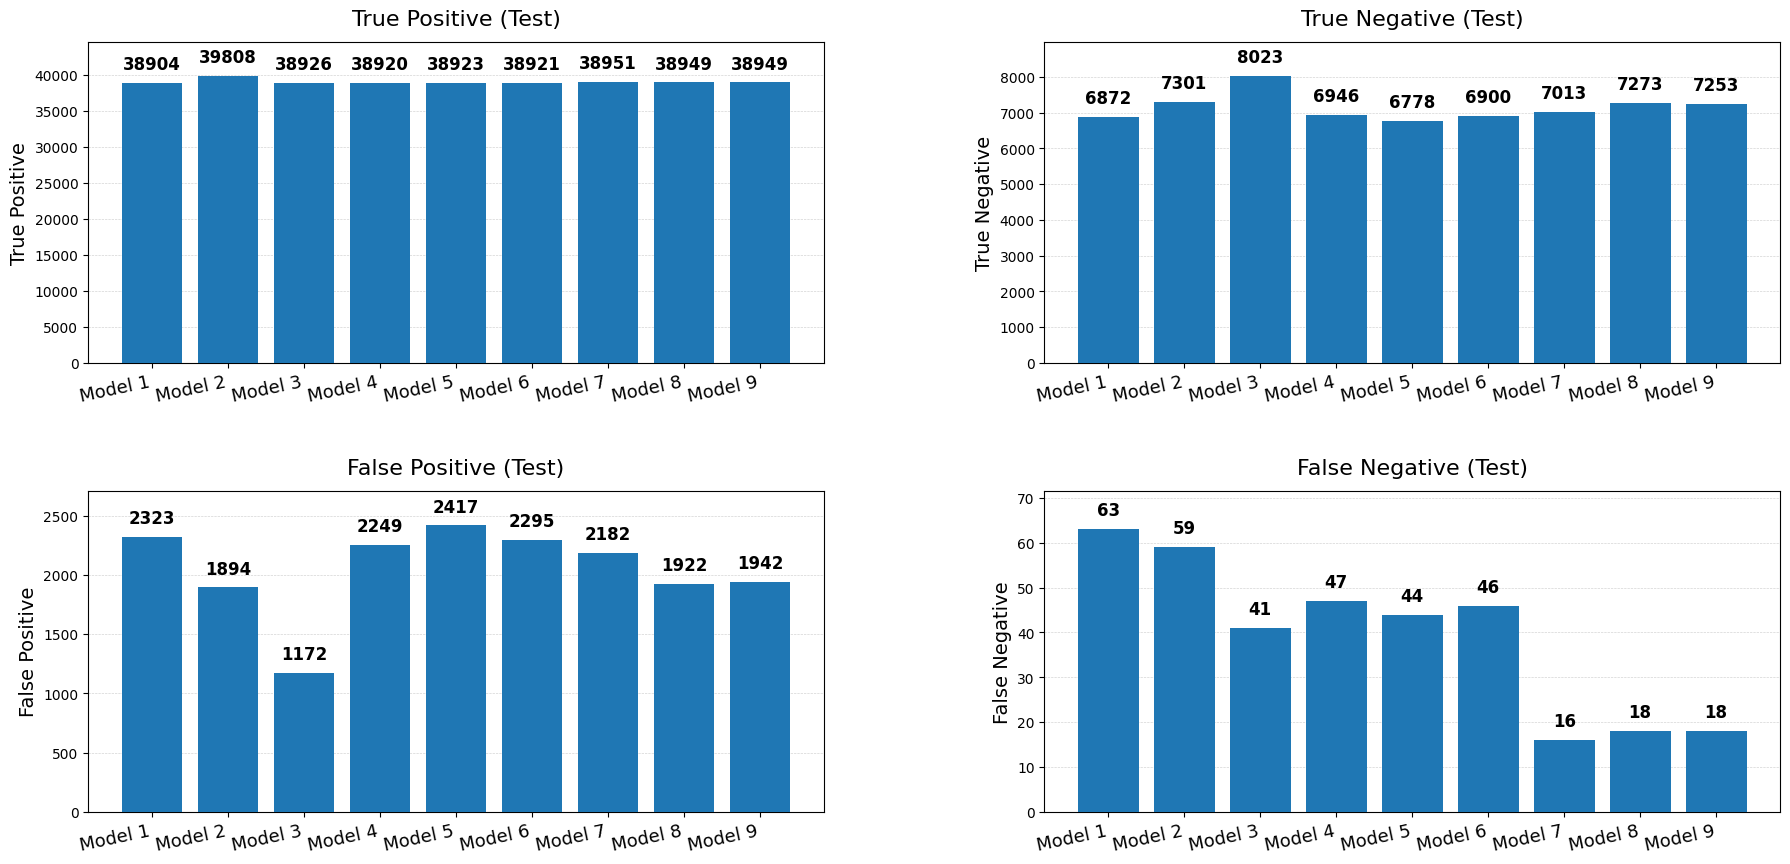

In [41]:
# column name variants to resolve
col_variants = {
    "True_Positive": ["True_Positive", "True Positive", "TP", "TruePositive"],
    "True_Negative": ["True_Negative", "True Negative", "TN", "TrueNegative"],
    "False_Positive": ["False_Positive", "False Positive", "FP", "FalsePositive"],
    "False_Negative": ["False_Negative", "False Negative", "FN", "FalseNegative"],
}

# resolve actual column names present in df
resolved = {}
for canon, variants in col_variants.items():
    for name in variants:
        if name in autoencoders_confusion_matrix_test.columns:
            resolved[canon] = name
            break
    else:
        raise KeyError(f"Could not find any column for '{canon}'. Tried: {variants}. Available: {list(autoencoders_confusion_matrix_train.columns)}")

# tick labels: prefer Model column if present, otherwise generate "Model 1"...
if "Model" in autoencoders_confusion_matrix_test.columns:
    tick_labels = autoencoders_confusion_matrix_test["Model"].astype(str).tolist()
else:
    tick_labels = [f"Model {i+1}" for i in range(len(autoencoders_confusion_matrix_test))]

x = np.arange(len(autoencoders_confusion_matrix_test))

# ------- PLOTTING (wider & larger) -------
figsize = (18, 10)         # <-- slightly wider
fig, axes = plt.subplots(2, 2, figsize=figsize)
axes = axes.flatten()

# font sizes tuned for readability
title_fs = 16
ylabel_fs = 14
xtick_fs = 13    # larger x tick labels
annot_fs = 12
show_values = True

order = ["True_Positive", "True_Negative", "False_Positive", "False_Negative"]
pretty = {
    "True_Positive": "True Positive",
    "True_Negative": "True Negative",
    "False_Positive": "False Positive",
    "False_Negative": "False Negative",
}

for ax, canon in zip(axes, order):
    colname = resolved[canon]
    vals = pd.to_numeric(autoencoders_confusion_matrix_test[colname].astype(str).str.replace(r"\s+", "", regex=True), errors="coerce").fillna(0).astype(int).values

    bars = ax.bar(x, vals, zorder=3)

    top = vals.max() if len(vals) else 0
    ax.set_ylim(0, top * 1.12 + 1)

    ax.set_title(f"{pretty[canon]} (Test)", fontsize=title_fs, pad=12)
    ax.set_ylabel(pretty[canon], fontsize=ylabel_fs)

    # wider spacing + larger readable labels; slight rotation (12 deg)
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=12, ha="right", fontsize=xtick_fs)

    ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.6, zorder=0)

    if show_values:
        for rect in bars:
            h = rect.get_height()
            ax.annotate(
                f"{int(round(h))}",
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=annot_fs, fontweight="bold"
            )

# layout adjustments: more bottom margin so labels fit comfortably
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.subplots_adjust(hspace=0.40, wspace=0.30, bottom=0.18, top=0.95)

plt.show()